In [287]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
from skimage.morphology import skeletonize
from shapely.geometry import box
import geopandas as gpd
import pandas as pd
from rasterio.transform import xy
from shapely.geometry import Point


from shapely.geometry import (
    Point,
    LineString,
)




TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"
MILES_TO_METERS = 1609.344

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [323]:
# Load data
ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental features
ILRoads2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_prisecroads/tl_2025_17_prisecroads.shp').to_crs(TARGET_CRS)
ILTollways2025 = gpd.read_file("./maps/raw/IL/TollwayReferenceLines.gdb").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)


# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(
c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'TollwayReferenceLines.gdb': 'NewReferenceLine' (default), 'ReferenceLine'. Specify layer parameter to avoid this warning.
  result = read_func(


In [324]:
def rasterize_roads_data(target : gpd.GeoDataFrame):
    
    minx, miny, maxx, maxy = target.total_bounds

    PIXEL_SIZE = MILES_TO_METERS * 0.1

    width = int(
        np.ceil(
            (maxx - minx) / PIXEL_SIZE
        )
    )

    height = int(
        np.ceil(
            (maxy - miny) / PIXEL_SIZE
        )
    )

    transform = from_origin(
        minx,
        maxy,
        PIXEL_SIZE,
        PIXEL_SIZE
    )

    road_mask = rasterize(
        [
            (geom, 1)
            for geom in target.geometry
            if geom is not None
        ],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        default_value=1,
        all_touched=True,
        dtype=np.uint8
    )

    ROAD_HALF_WIDTH = 0.25 * MILES_TO_METERS  # meters

    road_corridors = target.geometry.buffer(
        ROAD_HALF_WIDTH
    )

    road_mask = rasterize(
        [
            (geom, 1)
            for geom in road_corridors
            if geom is not None
        ],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        default_value=1,
        all_touched=True,
        dtype=np.uint8
    )



    skeleton = skeletonize(
        road_mask.astype(bool)
    )

    return skeleton, transform


In [325]:
data = ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'S')
)]

skeleton, transform = rasterize_roads_data(data)


In [326]:
import networkx as nx

G_skeleton = nx.Graph()

rows, cols = np.where(skeleton)

for row, col in zip(rows, cols):

    G_skeleton.add_node(
        (row, col)
    )

    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:

            if dr == 0 and dc == 0:
                continue

            neighbor = (
                row + dr,
                col + dc
            )

            if (
                0 <= neighbor[0] < skeleton.shape[0]
                and
                0 <= neighbor[1] < skeleton.shape[1]
                and
                skeleton[neighbor]
            ):
                G_skeleton.add_edge(
                    (row, col),
                    neighbor
                )

In [327]:
def pixel_to_point(row, col):

    x, y = xy(
        transform,
        row,
        col,
        offset="center"
    )

    return x, y

In [328]:
def get_closest_vertex(
    point,
    G,
):
    """
    Return the closest graph vertex to a Shapely Point.

    Assumes graph node IDs are coordinate tuples:
    (x, y)
    """

    return min(
        G.nodes,
        key=lambda node: point.distance(
            Point(node)
        )
    )

In [329]:
from shapely.geometry import LineString
import geopandas as gpd

# Nodes where a centerline segment starts/ends
key_nodes = {
    node
    for node, degree in G_skeleton.degree()
    if degree != 2
}

centerline_records = []
visited_edges = set()

for start in key_nodes:

    for neighbor in G_skeleton.neighbors(start):

        edge_key = frozenset((start, neighbor))

        if edge_key in visited_edges:
            continue

        # Start tracing a centerline chain
        pixel_path = [start, neighbor]

        previous = start
        current = neighbor

        visited_edges.add(edge_key)

        # Continue through degree-2 pixels
        while (
            G_skeleton.degree(current) == 2
            and current not in key_nodes
        ):

            next_nodes = [
                n
                for n in G_skeleton.neighbors(current)
                if n != previous
            ]

            if not next_nodes:
                break

            next_node = next_nodes[0]

            visited_edges.add(
                frozenset((current, next_node))
            )

            pixel_path.append(next_node)

            previous = current
            current = next_node

        # Convert pixel path to projected coordinates
        coordinates = [
            pixel_to_point(row, col)
            for row, col in pixel_path
        ]

        # Require at least two unique coordinates
        if len(coordinates) >= 2:

            centerline_records.append({
                "start_pixel": start,
                "end_pixel": current,
                "pixel_count": len(pixel_path),
                "geometry": LineString(coordinates)
            })

In [330]:
ILCenterlines = gpd.GeoDataFrame(
    centerline_records,
    geometry="geometry",
    crs=TARGET_CRS
)

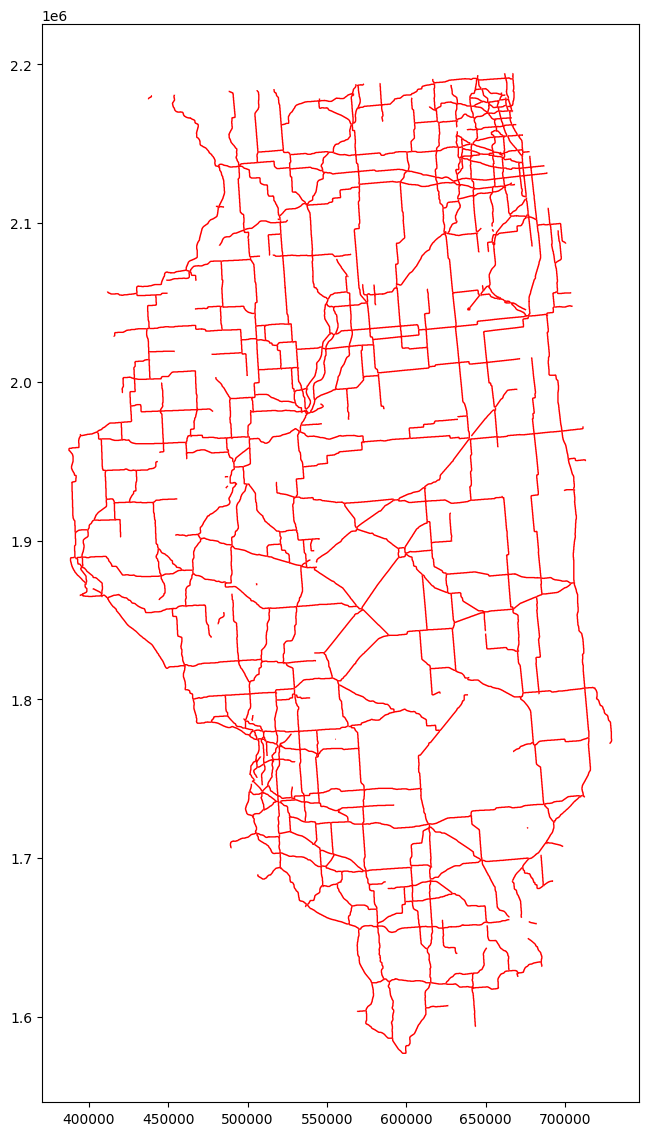

In [331]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(14, 14)
)

# Raster-derived centerlines
ILCenterlines.plot(
    ax=ax,
    color="red",
    linewidth=1,
    zorder=2
)

plt.show()

In [332]:
import geopandas as gpd
from shapely.ops import unary_union, linemerge

# Make sure everything uses a projected CRS in meters
roads = ILCenterlines.copy()

# Keep only valid line geometries
roads = roads[
    roads.geometry.notna()
    & ~roads.geometry.is_empty
].copy()

# Fix invalid geometries if necessary
roads["geometry"] = roads.geometry.make_valid()

In [333]:
# Combine the entire road network
network_union = unary_union(roads.geometry)

# Split every line wherever another line intersects it
# The result is usually a MultiLineString containing atomic segments
noded = linemerge(network_union)

# Convert back into a GeoDataFrame
atomic_roads = gpd.GeoDataFrame(
    geometry=[noded],
    crs=roads.crs
)

# Explode MultiLineStrings into individual road segments
atomic_roads = atomic_roads.explode(
    index_parts=False
).reset_index(drop=True)

# Keep only LineStrings
atomic_roads = atomic_roads[
    atomic_roads.geometry.geom_type == "LineString"
].copy()

In [334]:
atomic_roads["length_miles"] = (
    atomic_roads.geometry.length / 1609.344
).round(4)

In [335]:
atomic_roads

,geometry,length_miles
0,"LINESTRING (391202.695 1889374.96, 391041.761 ...",0.1000
1,"LINESTRING (391041.761 1889374.96, 391202.695 ...",0.1414
2,"LINESTRING (391041.761 1889374.96, 390880.827 ...",13.9439
3,"LINESTRING (391202.695 1889374.96, 391363.63 1...",0.1000
4,"LINESTRING (391202.695 1889374.96, 391202.695 ...",0.1000
...,...,...
4040,"LINESTRING (714841.774 1775755.274, 715002.708...",0.1000
4041,"LINESTRING (714841.774 1775755.274, 715002.708...",0.1414
4042,"LINESTRING (714841.774 1775755.274, 715002.708...",0.1414
4043,"LINESTRING (715002.708 1775594.339, 715002.708...",0.1000


In [336]:
import networkx as nx
from shapely.geometry import LineString, MultiLineString

# Undirected graph
G = nx.Graph()

for road_id, road in atomic_roads.iterrows():

    geom = road.geometry

    # Skip missing or empty geometries
    if geom is None or geom.is_empty:
        continue

    # Atomic roads should normally be LineStrings
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    else:
        parts = [geom]

    for part_num, line in enumerate(parts):

        # Get the two endpoint coordinates
        start = tuple(line.coords[0])
        end = tuple(line.coords[-1])

        # Add the edge with miles as the routing weight
        G.add_edge(
            start,
            end,
            road_id=road_id,
            part_num=part_num,
            length_miles=road["length_miles"],
            geometry=line,
        )

print(
    f"Graph has {G.number_of_nodes():,} nodes "
    f"and {G.number_of_edges():,} edges"
)

Graph has 2,580 nodes and 4,039 edges


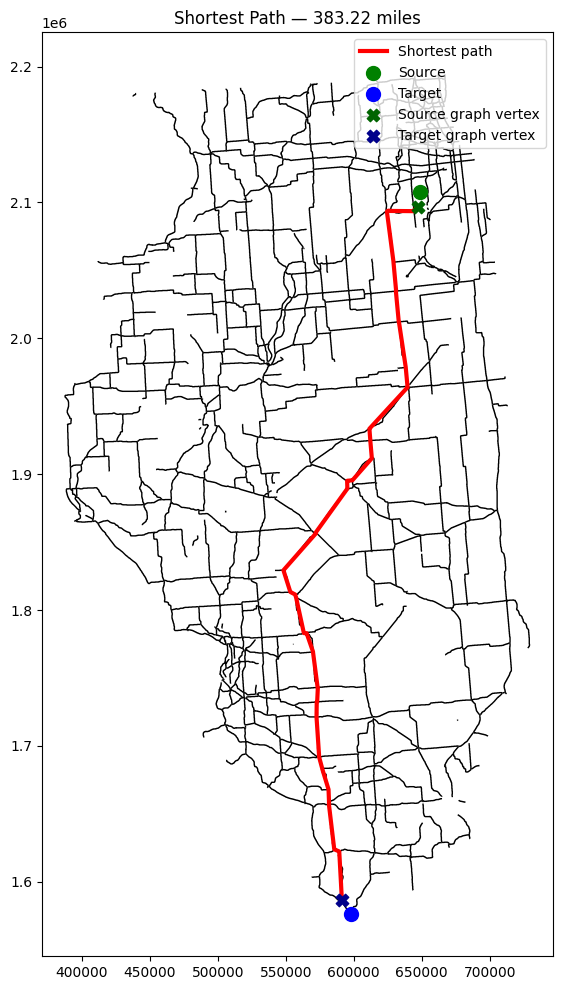

In [337]:
 # Find closest graph node to source

weight = "length_miles"


source_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Naperville')
)].iloc[0]


target_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'Cairo')
)].iloc[0]

source_node = get_closest_vertex(source_point.geometry.representative_point(), G)
target_node = get_closest_vertex(target_point.geometry.representative_point(), G)

# Run shortest path using edge mileage
route_nodes = nx.shortest_path(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
)

route_miles = nx.shortest_path_length(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
    )


import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Convert the ordered route nodes into a line
route_line = LineString(route_nodes)

# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# Plot all atomic roads
atomic_roads.plot(
    ax=ax,
    color="black",
    linewidth=1,
)

# Plot the shortest path
ax.plot(
    *route_line.xy,
    color="red",
    linewidth=3,
    label="Shortest path",
)

# Plot the original source and target representative points
ax.scatter(
    source_point.geometry.representative_point().x,
    source_point.geometry.representative_point().y,
    color="green",
    s=100,
    marker="o",
    label="Source",
    zorder=5,
)

ax.scatter(
    target_point.geometry.representative_point().x,
    target_point.geometry.representative_point().y,
    color="blue",
    s=100,
    marker="o",
    label="Target",
    zorder=5,
)

# Plot the graph vertices used for routing
ax.scatter(
    source_node[0],
    source_node[1],
    color="darkgreen",
    s=80,
    marker="X",
    label="Source graph vertex",
    zorder=6,
)

ax.scatter(
    target_node[0],
    target_node[1],
    color="darkblue",
    s=80,
    marker="X",
    label="Target graph vertex",
    zorder=6,
)

ax.legend()

ax.set_title(
    f"Shortest Path — {route_miles:.2f} miles"
)

plt.show()

In [ ]:
# ILCenterlines["geometry"] = (
#     ILCenterlines.geometry
#     .simplify(
#         tolerance=MILES_TO_METERS*0.5,          # meters
#         preserve_topology=True
#     )
# )

In [338]:
atomic_roads.to_file("./maps/raw/IL_StateHighways_Centerlines.geojson")